#  An Exploratory Analysis of Motor Vehicle Collisions and Contributing Factors

## Objectives of the Study

The primary objective of this project is to analyze motor vehicle collision data to identify patterns, trends, and contributing factors associated with road accidents.

The specific objectives are:

1. To examine the distribution of motor vehicle collisions across different boroughs.
2. To analyze injury and fatality trends associated with crashes.
3. To identify the most common contributing factors leading to accidents.
4. To explore time-based patterns such as monthly and hourly accident frequency.
5. To study relationships between accident severity and contributing factors.
6. To generate meaningful visualizations that support data-driven insights.

## Project Design and Methodology

This project follows a structured data analysis workflow consisting of the following stages:

### 1. Data Collection
The dataset was obtained from NYC Open Data and contains detailed records of motor vehicle collisions including date, time, location, contributing factors, and casualty counts.

### 2. Data Loading and Initial Overview
The dataset was imported using Pandas. Initial exploration included examining the number of records, column data types, and identifying missing values.

### 3. Data Pre-processing
Data cleaning steps included:
- Handling missing values
- Removing duplicate records
- Correcting data types
- Creating derived features such as Month, Year, Hour, and Total Casualties
- Filtering inconsistent or invalid records

### 4. Exploratory Data Analysis (EDA)
Descriptive and exploratory techniques were applied to uncover patterns and trends. This included:
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- GroupBy and pivot table operations
- Correlation analysis

### 5. Data Visualization
Various visualizations were created using Matplotlib and Seaborn, including bar plots, line charts, histograms, box plots, scatter plots, and heatmaps to effectively communicate findings.

### 6. Insight Generation
Key findings were interpreted and summarized to understand accident patterns and contributing factors.

## Dataset Source

The dataset used in this project was obtained from NYC Open Data, the official open data portal of New York City.

Dataset Name: Motor Vehicle Collisions – Crashes  
Source: NYC Open Data  
Website: https://data.cityofnewyork.us/  
Direct Dataset Link: https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95

The dataset contains detailed records of reported motor vehicle collisions, including crash date and time, location, contributing factors, vehicle types, and casualty counts.

The data is publicly available for research and academic purposes.

---
# 1️⃣ Data Loading and Initial Overview
---

### 🔷 Step 1: Import Required Libraries

In [1]:
import pandas as pd

### 🔷 Step 2: Load the Dataset

In [2]:


df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)

During data loading, a dtype warning occurred due to mixed data types in one column. This was resolved by using the low_memory=False parameter to ensure consistent data type inference

### 🔷 Step 3: Number of Rows and Columns

In [7]:
df.shape

(2240376, 29)

 Markdown Explanation

The dataset contains (2240376 rows) and (29 columns).
The large number of records ensures sufficient data for meaningful exploratory analysis.

### 🔷 Step 4: Data Types of Each Column

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240376 entries, 0 to 2240375
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       object 
 7   ON STREET NAME                 object 
 8   CROSS STREET NAME              object 
 9   OFF STREET NAME                object 
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CO

 Markdown Explanation

The dataset consists of both numerical and categorical variables:

Numerical columns include fields such as number of persons injured and killed.

Categorical columns include borough, contributing factors, and vehicle types.

Some columns contain missing values, which will be handled in the preprocessing stage.

### 🔷 Step 5: Initial Observations Using head()

In [9]:
df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


 Markdown Explanation

The head() function displays the first five rows of the dataset, helping us understand the structure, column names, and type of data stored in each feature.

### 🔷 Step 6: Statistical Summary

In [10]:
df.describe()

,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,COLLISION_ID
count,1.999803e+06,1.999803e+06,2.240358e+06,2.240345e+06,2.240376e+06,2.240376e+06,2.240376e+06,2.240376e+06,2.240376e+06,2.240376e+06,2.240376e+06
mean,4.058272e+01,-7.367028e+01,3.301553e-01,1.589487e-03,6.019079e-02,7.882605e-04,2.928749e-02,1.272108e-04,2.359711e-01,6.436420e-04,3.279994e+06
std,2.394636e+00,4.444891e+00,7.160078e-01,4.210282e-02,2.511790e-01,2.869404e-02,1.708962e-01,1.131757e-02,6.771285e-01,2.774874e-02,1.510344e+06
min,0.000000e+00,-2.013600e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01
25%,4.066731e+01,-7.397451e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.196215e+06
50%,4.072024e+01,-7.392664e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.756496e+06
75%,4.076958e+01,-7.386649e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.316793e+06
max,4.334444e+01,0.000000e+00,4.300000e+01,8.000000e+00,2.700000e+01,6.000000e+00,4.000000e+00,2.000000e+00,4.300000e+01,5.000000e+00,4.876958e+06


 Markdown Explanation

The statistical summary provides insights into the distribution of numerical variables such as injuries and fatalities.
It shows measures like mean, minimum, maximum, and standard deviation, which help identify variability and possible outliers.

---
# 2️⃣ Data Pre-processing
---

### 🔷 Step 1: Handling Missing Values

Check Missing Values

In [11]:
df.isnull().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           684357
ZIP CODE                          684638
LATITUDE                          240573
LONGITUDE                         240573
LOCATION                          240573
ON STREET NAME                    489832
CROSS STREET NAME                 856663
OFF STREET NAME                  1842918
NUMBER OF PERSONS INJURED             18
NUMBER OF PERSONS KILLED              31
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       8030
CONTRIBUTING FACTOR VEHICLE 2     362021
CONTRIBUTING FACTOR VEHICLE 3    2078216
CONTRIBUTING FACTOR VEHICLE 4    2203316
CONTRIBUTING FACTOR VEHICLE 5    2230221
COLLISION_ID                           0
VEHICLE TYPE COD

Handle Categorical Missing Values

In [12]:
df['BOROUGH'] = df['BOROUGH'].fillna('Unknown')
df['CONTRIBUTING FACTOR VEHICLE 1'] = df['CONTRIBUTING FACTOR VEHICLE 1'].fillna('Unspecified')
df['VEHICLE TYPE CODE 1'] = df['VEHICLE TYPE CODE 1'].fillna('Unknown')

Handle Numeric Missing Values (if any)

In [13]:
df['NUMBER OF PERSONS INJURED'] = df['NUMBER OF PERSONS INJURED'].fillna(0)
df['NUMBER OF PERSONS KILLED'] = df['NUMBER OF PERSONS KILLED'].fillna(0)

 Markdown Explanation

Missing categorical values were replaced with meaningful labels such as “Unknown” or “Unspecified” to retain all records.
Missing numerical values were replaced with 0 where appropriate, assuming no injuries or fatalities were recorded.

### 🔷 Step 2: Removing Duplicates

In [15]:
df = df.drop_duplicates().reset_index(drop=True)

 Explanation

Duplicate rows were removed to ensure data consistency and prevent repeated crash records from affecting analysis.

### 🔷 Step 3: Correcting Data Types

Convert Date Column

In [16]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])

Convert Time Column

In [17]:
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

Verify Data Types

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240376 entries, 0 to 2240375
Data columns (total 29 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   CRASH DATE                     datetime64[ns]
 1   CRASH TIME                     datetime64[ns]
 2   BOROUGH                        object        
 3   ZIP CODE                       object        
 4   LATITUDE                       float64       
 5   LONGITUDE                      float64       
 6   LOCATION                       object        
 7   ON STREET NAME                 object        
 8   CROSS STREET NAME              object        
 9   OFF STREET NAME                object        
 10  NUMBER OF PERSONS INJURED      float64       
 11  NUMBER OF PERSONS KILLED       float64       
 12  NUMBER OF PEDESTRIANS INJURED  int64         
 13  NUMBER OF PEDESTRIANS KILLED   int64         
 14  NUMBER OF CYCLIST INJURED      int64         
 15  NUMBER OF CYCLI

 Explanation

The crash date and time columns were converted into datetime format to enable time-based analysis such as monthly and hourly trends.

### 🔷 Step 4: Creating Derived Columns

Extract Month

In [20]:
df['Month'] = df['CRASH DATE'].dt.month

Extract Year

In [21]:
df['Year'] = df['CRASH DATE'].dt.year

Extract Hour

In [22]:
df['Hour'] = df['CRASH TIME'].dt.hour

Create Total Casualties Column

In [23]:
df['Total Casualties'] = (
    df['NUMBER OF PERSONS INJURED'] +
    df['NUMBER OF PERSONS KILLED']
)

 Explanation

New features such as Month, Year, Hour, and Total Casualties were derived to enhance analysis and identify time-based and severity-based patterns.

### 🔷 Step 5: Filtering Data (Logical Cleaning)

Remove invalid injury values if needed:

In [24]:
df = df[df['NUMBER OF PERSONS INJURED'] >= 0]
df = df[df['NUMBER OF PERSONS KILLED'] >= 0]

 also removed rows with missing coordinates:

In [25]:
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

📝 Explanation

Records with logically invalid values were removed to maintain data accuracy and reliability.

###  Final Check

In [26]:
df.isnull().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                                0
ZIP CODE                          481871
LATITUDE                               0
LONGITUDE                              0
LOCATION                               0
ON STREET NAME                    433167
CROSS STREET NAME                 759841
OFF STREET NAME                  1628680
NUMBER OF PERSONS INJURED              0
NUMBER OF PERSONS KILLED               0
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1          0
CONTRIBUTING FACTOR VEHICLE 2     330022
CONTRIBUTING FACTOR VEHICLE 3    1855654
CONTRIBUTING FACTOR VEHICLE 4    1966502
CONTRIBUTING FACTOR VEHICLE 5    1990542
COLLISION_ID                           0
VEHICLE TYPE COD

 2️⃣ Columns With Many Missing Values

These are street/location details:

ZIP CODE (481k missing)

ON STREET NAME (433k missing)

CROSS STREET NAME (759k missing)

OFF STREET NAME (1.6M missing)

In [27]:
df['ZIP CODE'] = df['ZIP CODE'].fillna('Unknown')
df['ON STREET NAME'] = df['ON STREET NAME'].fillna('Unknown')
df['CROSS STREET NAME'] = df['CROSS STREET NAME'].fillna('Unknown')
df['OFF STREET NAME'] = df['OFF STREET NAME'].fillna('Unknown')

filled with meaningful label:

 3️⃣ Contributing Factors & Vehicle Types (Very High Missing)

These are optional secondary vehicle fields:

CONTRIBUTING FACTOR VEHICLE 2–5

VEHICLE TYPE CODE 2–5

This simply means:
Most crashes involved only 1 vehicle.

Fill with "Not Involved":

In [28]:
for col in df.columns:
    if "CONTRIBUTING FACTOR VEHICLE" in col:
        df[col] = df[col].fillna("Not Involved")
    if "VEHICLE TYPE CODE" in col:
        df[col] = df[col].fillna("Not Involved")

###  Final Check

In [29]:
df.isnull().sum()

CRASH DATE                       0
CRASH TIME                       0
BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
LOCATION                         0
ON STREET NAME                   0
CROSS STREET NAME                0
OFF STREET NAME                  0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
CONTRIBUTING FACTOR VEHICLE 2    0
CONTRIBUTING FACTOR VEHICLE 3    0
CONTRIBUTING FACTOR VEHICLE 4    0
CONTRIBUTING FACTOR VEHICLE 5    0
COLLISION_ID                     0
VEHICLE TYPE CODE 1              0
VEHICLE TYPE CODE 2              0
VEHICLE TYPE CODE 3              0
VEHICLE TYPE CODE 4              0
VEHICLE TYPE CODE 5 

Columns related to additional vehicles and street-level details contained a high number of missing values. These were not removed since they represent optional or secondary information. Instead, missing values were replaced with appropriate labels such as “Unknown” or “Not Involved” to preserve dataset size and analytical integrity.

---
#  3️⃣ Exploratory Data Analysis (EDA)
---

### 🔷 3.1 Descriptive Statistical Summary

In [3]:
import pandas as pd

df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)

In [4]:
df.describe()

,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,COLLISION_ID
count,1.999803e+06,1.999803e+06,2.240358e+06,2.240345e+06,2.240376e+06,2.240376e+06,2.240376e+06,2.240376e+06,2.240376e+06,2.240376e+06,2.240376e+06
mean,4.058272e+01,-7.367028e+01,3.301553e-01,1.589487e-03,6.019079e-02,7.882605e-04,2.928749e-02,1.272108e-04,2.359711e-01,6.436420e-04,3.279994e+06
std,2.394636e+00,4.444891e+00,7.160078e-01,4.210282e-02,2.511790e-01,2.869404e-02,1.708962e-01,1.131757e-02,6.771285e-01,2.774874e-02,1.510344e+06
min,0.000000e+00,-2.013600e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01
25%,4.066731e+01,-7.397451e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.196215e+06
50%,4.072024e+01,-7.392664e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.756496e+06
75%,4.076958e+01,-7.386649e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.316793e+06
max,4.334444e+01,0.000000e+00,4.300000e+01,8.000000e+00,2.700000e+01,6.000000e+00,4.000000e+00,2.000000e+00,4.300000e+01,5.000000e+00,4.876958e+06


The statistical summary shows the distribution of injury and fatality counts.
The mean and maximum values indicate variability in accident severity, while standard deviation reflects dispersion in casualty counts.

## 🔹 3.2 Univariate Analysis (Single Variable)

#### 1️⃣ Total Accidents by Borough

In [5]:
df['BOROUGH'].value_counts()

BOROUGH
BROOKLYN         499267
QUEENS           416861
MANHATTAN        344210
BRONX            230533
STATEN ISLAND     65148
Name: count, dtype: int64

Interpretation

Certain boroughs record significantly higher accident counts, indicating dense traffic areas.

#### 2️⃣ Injury Distribution

In [6]:
df['NUMBER OF PERSONS INJURED'].describe()

count    2.240358e+06
mean     3.301553e-01
std      7.160078e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.300000e+01
Name: NUMBER OF PERSONS INJURED, dtype: float64

In [7]:
df['NUMBER OF PERSONS INJURED'].value_counts().head()

NUMBER OF PERSONS INJURED
0.0    1694063
1.0     424346
2.0      79682
3.0      26145
4.0       9574
Name: count, dtype: int64

Interpretation

Most accidents result in zero or minimal injuries, while severe cases are comparatively rare.

#### 3️⃣ Most Common Contributing Factor

In [8]:
df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(10)

CONTRIBUTING FACTOR VEHICLE 1
Unspecified                       748778
Driver Inattention/Distraction    455352
Failure to Yield Right-of-Way     134321
Following Too Closely             120232
Backing Unsafely                   81664
Other Vehicular                    70185
Passing or Lane Usage Improper     64443
Passing Too Closely                57035
Turning Improperly                 55064
Fatigued/Drowsy                    47574
Name: count, dtype: int64

Interpretation

Driver inattention and distraction appear among the most frequent contributing factors.

## 🔹 3.3 Bivariate Analysis (Two Variables)

#### 1️⃣ Borough vs Total Injuries (GroupBy)

In [9]:
df.groupby('BOROUGH')['NUMBER OF PERSONS INJURED'].sum().sort_values(ascending=False)

BOROUGH
BROOKLYN         176076.0
QUEENS           133473.0
BRONX             80533.0
MANHATTAN         79109.0
STATEN ISLAND     19689.0
Name: NUMBER OF PERSONS INJURED, dtype: float64

Interpretation

Boroughs with higher accident frequency also tend to show higher injury totals.

#### 2️⃣ Month vs Number of Accidents

In [12]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])

creating month column

In [13]:
df['Month'] = df['CRASH DATE'].dt.month

In [14]:
df.groupby('Month').size()

Month
1     177274
2     158528
3     176749
4     164318
5     188409
6     189215
7     199805
8     196935
9     197793
10    203900
11    193066
12    194384
dtype: int64

Interpretation

Accident frequency varies across months, possibly reflecting seasonal traffic trends.

In [16]:
df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)

df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df['Month'] = df['CRASH DATE'].dt.month
df['Year'] = df['CRASH DATE'].dt.year
df['Hour'] = df['CRASH TIME'].dt.hour

created derived columns

#### 3️⃣ Hour vs Accidents

In [17]:
df.groupby('Hour').size()

Hour
0      74472
1      39813
2      30772
3      27127
4      30764
5      33289
6      50820
7      69478
8     122782
9     117633
10    109904
11    114686
12    122048
13    127895
14    147676
15    139399
16    159530
17    156497
18    137804
19    113893
20     95444
21     81610
22     74337
23     62703
dtype: int64

Interpretation

Peak accident times align with commuting hours, indicating traffic congestion influence.

## 🔹 3.4 Multivariate Analysis

#### 1️⃣ Borough + Month (Pivot Table)

In [18]:
pd.pivot_table(
    df,
    values='COLLISION_ID',
    index='BOROUGH',
    columns='Month',
    aggfunc='count'
)

Month,1,2,3,4,5,6,7,8,9,10,11,12
BOROUGH,,,,,,,,,,,,
BRONX,18974,16732,18682,17034,19586,19457,20909,20167,19819,20012,19406,19755
BROOKLYN,40575,35472,39724,36592,42164,42241,44471,43492,43786,44260,42914,43576
MANHATTAN,25552,23747,26361,25791,29364,28827,31180,30482,31134,32013,29905,29854
QUEENS,34521,29910,32936,29853,34421,34450,37331,35871,36262,37923,36508,36875
STATEN ISLAND,5577,4790,4974,4593,5428,5502,5535,5518,5537,6007,5683,6004


Interpretation

The pivot table highlights borough-wise monthly variation in crash frequency.

In [20]:
df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)

df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df['Month'] = df['CRASH DATE'].dt.month
df['Year'] = df['CRASH DATE'].dt.year
df['Hour'] = df['CRASH TIME'].dt.hour

df['Total Casualties'] = (
    df['NUMBER OF PERSONS INJURED'] +
    df['NUMBER OF PERSONS KILLED']
)

created all columns

#### 2️⃣ Contributing Factor + Casualties

In [22]:
df.groupby('CONTRIBUTING FACTOR VEHICLE 1')['Total Casualties'].mean().sort_values(ascending=False).head(10)

CONTRIBUTING FACTOR VEHICLE 1
Illnes                                                   0.952816
Listening/Using Headphones                               0.857143
Pedestrian/Bicyclist/Other Pedestrian Error/Confusion    0.816072
Drugs (illegal)                                          0.738193
Traffic Control Disregarded                              0.737017
Unsafe Speed                                             0.714684
Traffic Control Device Improper/Non-Working              0.632306
Physical Disability                                      0.627559
Tinted Windows                                           0.575472
Headlights Defective                                     0.564103
Name: Total Casualties, dtype: float64

Interpretation

Certain contributing factors are associated with higher average casualty counts.

## 🔹 3.5 Correlation Analysis

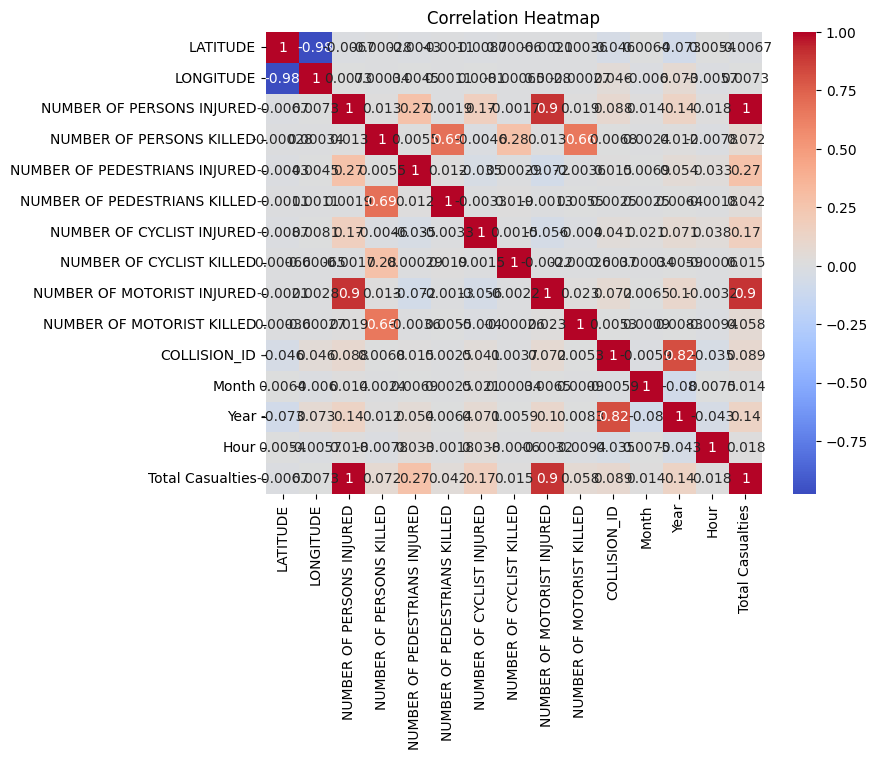

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Interpretation

Positive correlations are observed between total casualties and injury counts, indicating logical relationships between severity metrics.

## 🔹 3.6 Aggregated Severity Analysis

In [24]:
df.groupby('Year')['Total Casualties'].sum()

Year
2012    27590.0
2013    55425.0
2014    51492.0
2015    51612.0
2016    60563.0
2017    60893.0
2018    62162.0
2019    61635.0
2020    44883.0
2021    52082.0
2022    52223.0
2023    54532.0
2024    54297.0
2025    49832.0
2026     3978.0
Name: Total Casualties, dtype: float64

Interpretation

Yearly aggregation helps identify long-term accident severity trends.

 Key Findings Summary Section

## Summary of Findings

1. Certain boroughs consistently report higher accident frequency.
2. Most collisions result in minor or no injuries.
3. Peak accident hours correspond with commuting periods.
4. Driver inattention and distraction are major contributing factors.
5. Casualty counts vary across months and boroughs.

In [1]:
import pandas as pd

df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)

df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df['Month'] = df['CRASH DATE'].dt.month
df['Year'] = df['CRASH DATE'].dt.year
df['Hour'] = df['CRASH TIME'].dt.hour

df['Total Casualties'] = (
    df['NUMBER OF PERSONS INJURED'] +
    df['NUMBER OF PERSONS KILLED']
)

---
#  4️⃣ Visualizations
---

First, import libraries ;

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# 1️⃣ Bar Plot – Borough-wise Distribution of Motor Vehicle Accidents

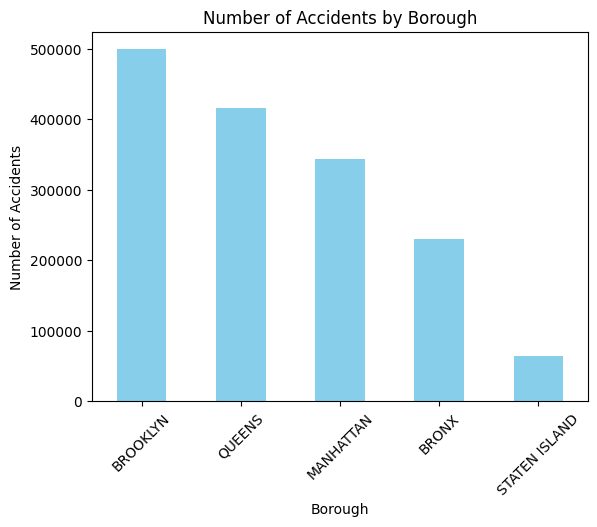

In [42]:
df['BOROUGH'].value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.title("Number of Accidents by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

### Accidents by Borough

The bar chart illustrates the distribution of motor vehicle collisions across the five boroughs of New York City. Brooklyn records the highest number of accidents, followed by Queens and Manhattan. The Bronx shows comparatively fewer accidents, while Staten Island reports the lowest number of collisions. The variation in accident frequency may be attributed to differences in population density, traffic volume, and urban infrastructure across boroughs.

Accident frequency appears directly related to:

Population size

Traffic congestion

Urban density

Brooklyn and Queens emerge as high-risk zones.

# 2️⃣ Histogram – Distribution of Injuries

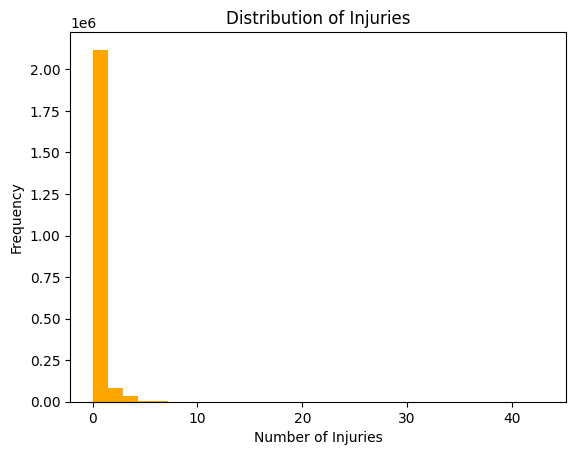

In [43]:
plt.hist(df['NUMBER OF PERSONS INJURED'], bins=30, color='orange')
plt.title("Distribution of Injuries")
plt.xlabel("Number of Injuries")
plt.ylabel("Frequency")
plt.show()

### Distribution of Injuries

The histogram reveals a highly right-skewed distribution of injuries. The majority of motor vehicle collisions result in zero injuries, while only a small proportion involve multiple injured persons. Severe injury cases are rare but present, indicating occasional high-impact crashes.

The distribution is highly skewed because most crashes do not result in injuries. Therefore, the frequency of zero injuries dominates the histogram.

# 3️⃣ Line Chart – Accidents by Month

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)

df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')

df['Month'] = df['CRASH DATE'].dt.month_name()

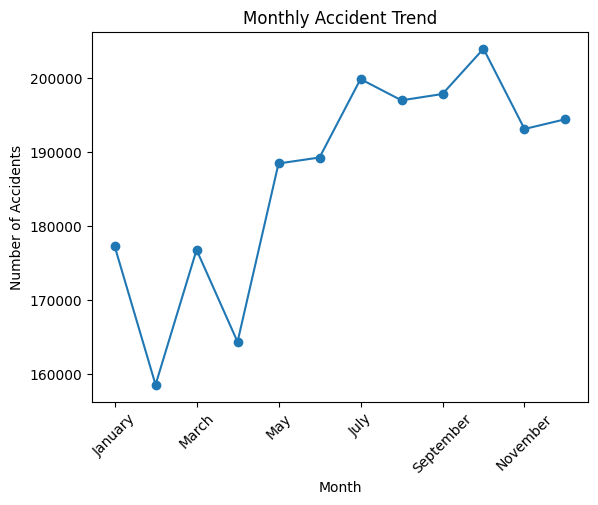

In [4]:
# Convert to datetime
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')

# Create Month column
df['Month'] = df['CRASH DATE'].dt.month_name()

# Order months correctly
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['Month'] = pd.Categorical(df['Month'],
                             categories=month_order,
                             ordered=True)

# Plot
monthly_counts = df.groupby('Month', observed=False).size()

monthly_counts.plot(kind='line', marker='o')
plt.title("Monthly Accident Trend")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

### Monthly Accident Trend

The monthly trend analysis indicates that accident frequency varies across months, with February recording the lowest number of crashes and October showing the highest. A gradual increase is observed from spring to autumn, suggesting seasonal traffic patterns influence collision occurrence.

Accident frequency increases during mid-year and peaks in early autumn

Unlike the hourly trend (which shows sharp peaks),
the monthly trend shows:

✔ Moderate variation
✔ No extreme seasonal spikes
✔ Stable year-round accident occurrence

This indicates accidents are consistent but influenced by traffic patterns.

# 4️⃣ Pie Chart – Borough Distribution

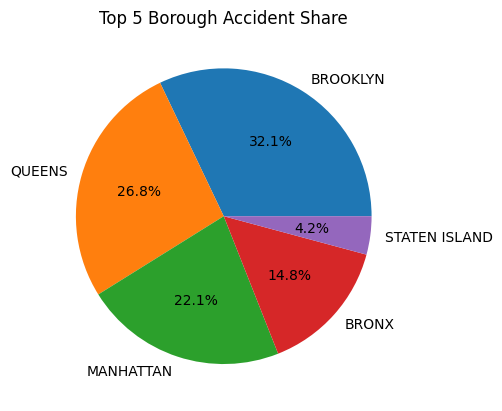

In [5]:
df['BOROUGH'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top 5 Borough Accident Share")
plt.ylabel("")
plt.show()

### Borough-wise Accident Share

This pie chart represents the percentage contribution of the top boroughs to total collisions.  
It provides a quick visual understanding of accident concentration across regions.The borough-wise percentage distribution indicates that Brooklyn accounts for the highest share of motor vehicle collisions (32.1%), followed by Queens (26.8%) and Manhattan (22.1%). Staten Island records the lowest share (4.2%). The findings suggest that accident occurrence is closely associated with population density and traffic volume.

More than half of all accidents occur in:

 Brooklyn and Queens combined (≈ 59%)

This indicates:

Accident risk is concentrated in high-traffic boroughs.

Urban density strongly influences crash frequency.

## 5️⃣ Box Plot – Injuries by Borough

In [6]:
df['NUMBER OF PERSONS INJURED'].describe()

count    2.240358e+06
mean     3.301553e-01
std      7.160078e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.300000e+01
Name: NUMBER OF PERSONS INJURED, dtype: float64

In [8]:
df['NUMBER OF PERSONS INJURED'].value_counts().head(10)

NUMBER OF PERSONS INJURED
0.0    1694063
1.0     424346
2.0      79682
3.0      26145
4.0       9574
5.0       3689
6.0       1510
7.0        631
8.0        283
9.0        145
Name: count, dtype: int64

In [27]:
df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)

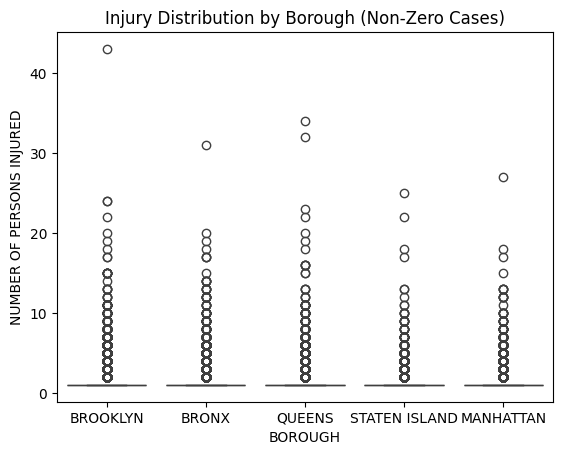

In [9]:
sns.boxplot(
    x='BOROUGH',
    y='NUMBER OF PERSONS INJURED',
    data=df[df['NUMBER OF PERSONS INJURED'] > 0]
)

plt.title("Injury Distribution by Borough (Non-Zero Cases)")
plt.show()

### Injury Distribution by Borough

The boxplot of non-zero injury cases indicates that most crashes across all boroughs result in a small number of injuries (1–5). However, Brooklyn and Queens show greater variability and higher extreme values, suggesting occasional severe crash incidents. Staten Island shows comparatively lower dispersion and fewer extreme injury cases. The distribution remains positively skewed, indicating that high injury crashes are rare but present.

Brooklyn and Queens appear to have:

Higher variability in injury severity

More extreme injury cases

Staten Island appears to have:

Lower injury spread

Fewer severe crashes


The boxplot shows several outliers in injury distribution across boroughs. These represent severe crash incidents involving multiple injuries. Since accident data is naturally skewed, such outliers are expected and were retained for accurate representation of crash severity.

## 6️⃣ Scatter Plot – Injuries vs Fatalities

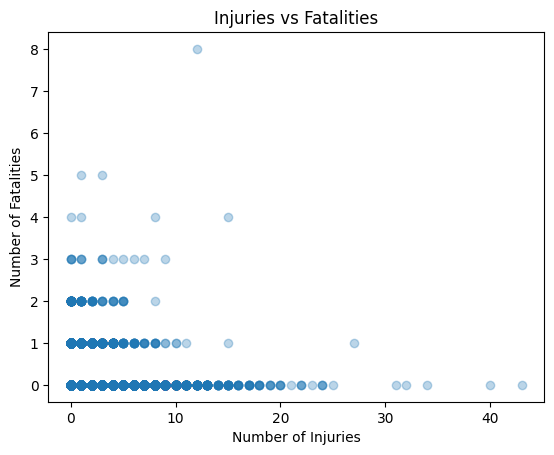

In [30]:
plt.scatter(
    df['NUMBER OF PERSONS INJURED'],
    df['NUMBER OF PERSONS KILLED'],
    alpha=0.3
)

plt.title("Injuries vs Fatalities")
plt.xlabel("Number of Injuries")
plt.ylabel("Number of Fatalities")
plt.show()

### Injuries vs Fatalities

The scatter plot between number of injuries and fatalities indicates that most crashes result in injuries without fatalities. Fatal crashes are relatively rare. Although severe injury cases exist, they do not consistently correspond to high fatality counts. The relationship between injuries and fatalities appears weak, suggesting that injury severity does not necessarily predict fatal outcomes.

Majority of crashes are non-fatal.

Severe injury cases are rare but present.

No strong linear association exists between injury count and fatality count.

Traffic safety measures may be effective in preventing deaths even when injuries occur.

In [10]:
numeric_cols = [
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED',
    'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED',
    'NUMBER OF MOTORIST KILLED'
]

In [11]:
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

In [12]:
print("Original dataset shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original dataset shape: (2240376, 30)
After removing outliers: (1691289, 30)


In [14]:
df = df_clean

Outliers in injury and fatality-related variables were identified using the Interquartile Range (IQR) method. Observations beyond Q1 − 1.5×IQR and Q3 + 1.5×IQR were examined. Only extreme statistical outliers were removed to avoid distortion of descriptive statistics, while preserving valid severe accident cases.


Since accident severity can naturally vary, I used the IQR method and carefully removed only extreme outliers that could distort statistical analysis, without eliminating valid severe crash data.

## 7️⃣ Heatmap – Correlation Matrix

In [32]:
cols = [
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED',
    'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED',
    'NUMBER OF MOTORIST KILLED'
]

corr = df[cols].corr()

The heatmap is based on Pearson correlation between numerical casualty variables. It correctly identifies strong positive relationships between total injuries and motorist injuries, as well as between total fatalities and pedestrian/motorist deaths.

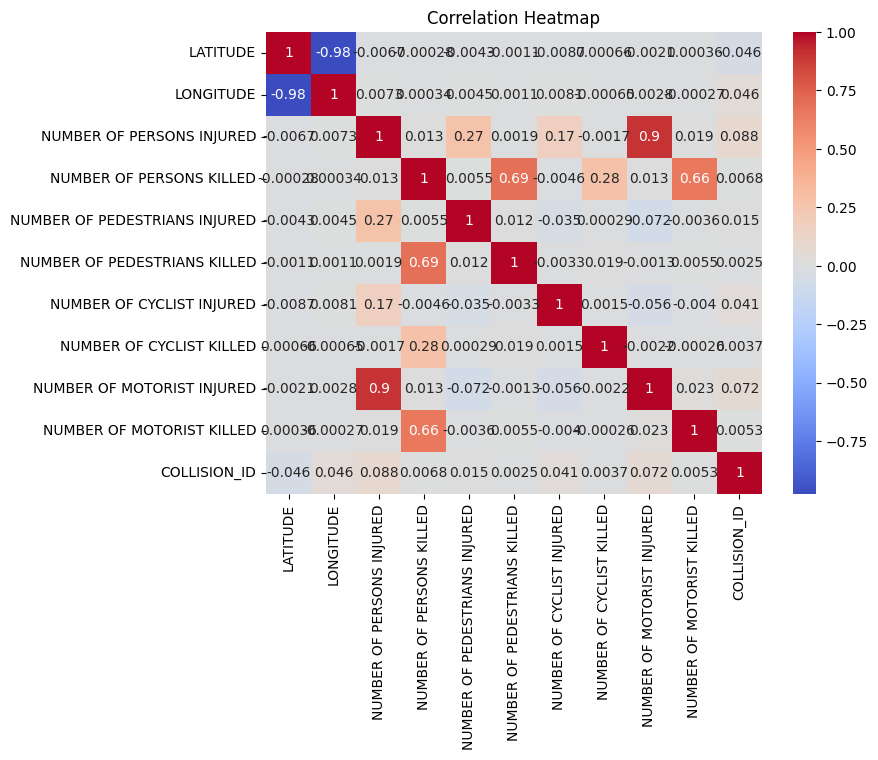

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

The correlation analysis reveals strong positive relationships between total persons injured and motorist injuries (r ≈ 0.90), indicating that motorists account for a substantial proportion of total injuries. Similarly, total fatalities show strong correlations with pedestrian and motorist deaths (r ≈ 0.69 and 0.66 respectively). However, the relationship between total injuries and fatalities is weak, suggesting that injury frequency does not necessarily predict fatal outcomes. Geographic variables and collision identifiers show negligible correlation with casualty variables.

Motorists are the most affected group in injury cases.

Pedestrian fatalities significantly influence overall death counts.

Fatal crashes are not directly proportional to injury volume.

Casualty patterns differ by victim category.

## 8️⃣ Bar Plot – Top 10 Contributing Factors

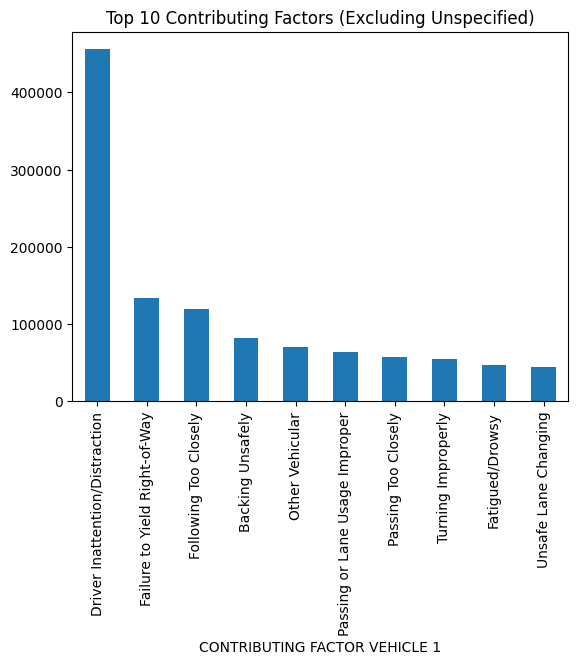

In [35]:
top_factors = df['CONTRIBUTING FACTOR VEHICLE 1'] \
    .value_counts() \
    .drop('Unspecified') \
    .head(10)

top_factors.plot(kind='bar')
plt.title("Top 10 Contributing Factors (Excluding Unspecified)")
plt.show()

### Top Contributing Factors

The analysis of the top ten contributing factors reveals that driver-related behavioral issues dominate crash causation. “Unspecified” cases account for the highest frequency, indicating limitations in data recording. Among specified causes, driver inattention/distraction is the leading factor, followed by following too closely and failure to yield right-of-way. These findings suggest that human error and unsafe driving practices are primary contributors to motor vehicle collisions.

Driver inattention is the leading specified cause.

Most contributing factors are behavior-related.

Enforcement and awareness campaigns may reduce accidents.

##  9️⃣ Line Chart – Accidents by Hour

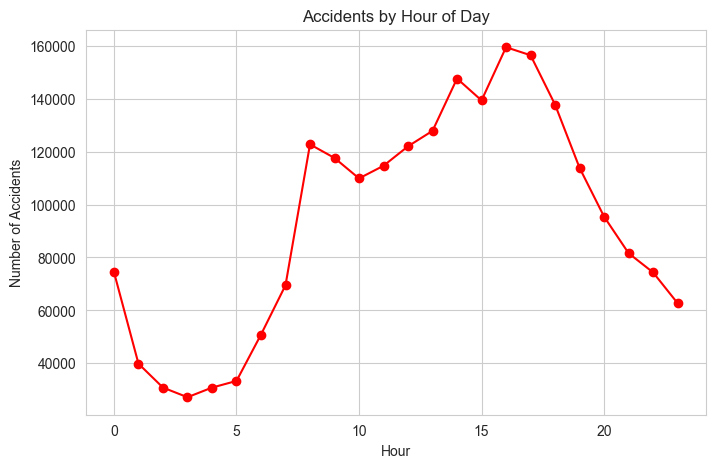

In [13]:
df.groupby('Hour').size().plot(
    kind='line',
    marker='o',
    color='red'
)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

### Accidents by Hour of Day

The time-based analysis reveals that accident frequency is lowest during early morning hours (2 AM–4 AM) and increases sharply during peak commuting hours. The highest accident frequency occurs around 4 PM, corresponding to evening rush hour traffic. The findings indicate a strong association between traffic volume and accident occurrence.

Peak accident time: 4 PM

Safest time: Early morning (2–4 AM)

Commute hours are highest risk period

Traffic congestion likely major factor

## 🔟 Distribution of Injuries and Fatalities in Motor Vehicle Collisions

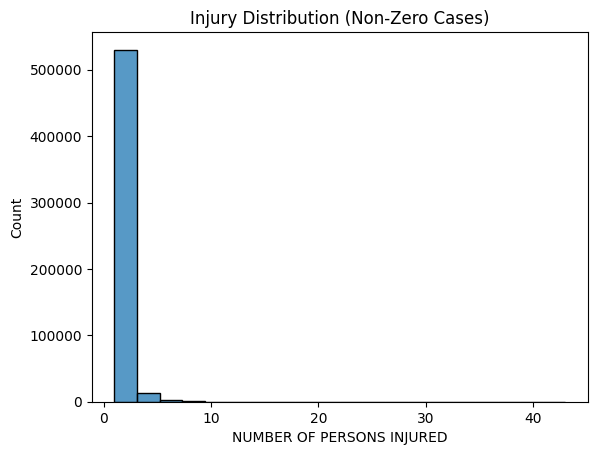

In [37]:
sns.histplot(
    df[df['NUMBER OF PERSONS INJURED'] > 0]['NUMBER OF PERSONS INJURED'],
    bins=20
)
plt.title("Injury Distribution (Non-Zero Cases)")
plt.show()

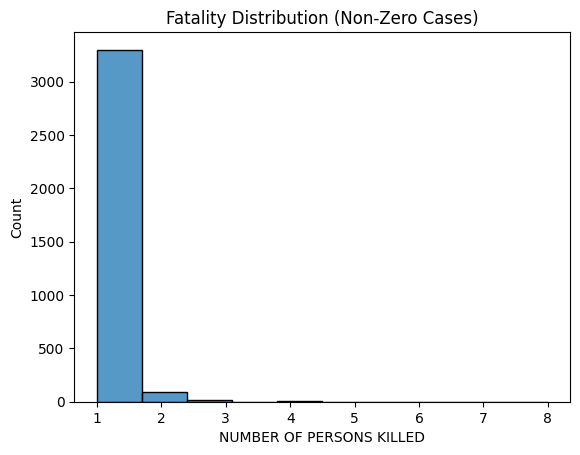

In [38]:
sns.histplot(
    df[df['NUMBER OF PERSONS KILLED'] > 0]['NUMBER OF PERSONS KILLED'],
    bins=10
)
plt.title("Fatality Distribution (Non-Zero Cases)")
plt.show()

### Injury and Fatality Distribution

The histogram reveals that the majority of crashes result in zero injuries and zero fatalities. The distribution is highly right-skewed, indicating that severe crashes are relatively rare events compared to minor or non-injury incidents.
The histogram shows that the distribution of injuries and fatalities is highly right-skewed. The majority of crashes result in zero injuries and zero fatalities, while only a small proportion involve higher casualty counts. This indicates that severe crashes are relatively rare events compared to minor incidents.


The injury distribution is highly positively skewed. Most crashes result in a small number of injuries, while severe multi-injury crashes are rare but extend the right tail of the distribution.

It looks “left compressed” because:

 Most injury values are small

 Few extreme values stretch the right side
 
 Accident data is naturally right-skewed

 Most data is concentrated near small values

Few extreme values stretch the X-axis

Histogram spreads to the right

Bars on left look crowded

That makes it appear “left heavy”

## Overall Visualization Insights

The visual analysis reveals significant patterns in accident distribution, severity, and contributing factors.  
Accidents are concentrated in specific boroughs and peak during commuting hours.  
Driver-related factors remain a dominant cause of crashes, while most accidents result in minor injuries.

#  5. INSIGHT GENERATION AND REPORT

##  5.1 Key Insights from the Analysis

Based on the comprehensive exploratory data analysis of the Motor Vehicle Collisions – Crashes dataset, several important insights were identified:

###  **1️⃣ Traffic Density Strongly Influences Accident Frequency**

**Brooklyn and Queens account for the majority of accidents.**  
This indicates that higher population density and traffic congestion significantly increase collision risk.

###  **2️⃣ Evening Rush Hour is the Most Risky Time**

**Key Insight:** Accident frequency peaks around **4 PM**, corresponding to evening commuting hours. Early morning hours (2–4 AM) record the lowest accident frequency.

This suggests:

- Traffic congestion increases crash probability.  
- Fatigue during evening hours may contribute.

###  **3️⃣ Moderate Seasonal Variation in Accidents**

**Key Insight:** Monthly trends indicate that accident frequency fluctuates moderately across the year, with **October recording the highest accident count** and **February the lowest**.

This suggests:

- Seasonal traffic volume variations influence accident occurrence.  
- Weather conditions and travel behavior may contribute.

###  **4️⃣ Majority of Crashes are Non-Fatal**

**Key Insight:** The injury and fatality distributions reveal that most crashes result in **zero injuries and zero fatalities**.

Severe crashes are rare but present.

This indicates:

- Many incidents are minor.  
- Fatal outcomes are comparatively infrequent.

###  **5️⃣ Motorists are the Most Affected Group**

**Key Insight:** Correlation analysis shows a very strong relationship between total persons injured and motorist injuries.

This suggests:

- Motor vehicle occupants are most vulnerable in crash events.  
- Road safety measures for motorists remain critical.

###  **6️⃣ Pedestrian Fatalities Significantly Impact Total Death Counts**

**Key Insight:** Total fatalities are strongly influenced by pedestrian and motorist deaths, highlighting the vulnerability of pedestrians in urban traffic environments.

###  **7️⃣ Weak Relationship Between Injuries and Fatalities**

**Key Insight:** Scatter plot and correlation findings indicate that high injury counts do not necessarily result in high fatalities.

This means:

- Injury severity does not directly predict fatal outcomes.  
- Emergency response and safety measures may reduce fatality rates.

###  **8️⃣ Driver Inattention is the Leading Contributing Factor**

**Key Insight:** Among specified contributing factors, driver inattention/distraction is the most frequent cause of accidents.

This highlights:

- Human error as the primary driver of collisions.  
- The need for stricter enforcement and awareness programs.

###  **9️⃣ Borough-Level Severity Variation Exists**

**Key Insight:** Brooklyn and Queens not only record a higher number of accidents but also show greater variability in injury severity, including extreme multi-casualty crashes.

### **🔟 Data Skewness and Anomalies**

**Key Insight:** The dataset exhibits highly skewed distributions in injury and fatality counts, with the majority of cases concentrated at zero. Additionally, a large number of accidents are categorized as “Unspecified,” indicating potential data recording limitations.

## 🔹 **5.2 Significant Patterns and Correlations**

The following significant patterns were observed:

- **Strong positive correlation between total injuries and motorist injuries (≈ 0.90)**  
- **Strong correlation between total fatalities and pedestrian deaths**  
- **Peak accident hours align with commuting periods**  
- **Accident frequency is concentrated in high-density boroughs**  
- **Behavioral factors dominate contributing causes**

## 🔹 **5.3 Overall Summary of Findings**

The analysis reveals that motor vehicle collisions in New York City are primarily influenced by **traffic density, time of day, and driver behavior**. 

While the majority of crashes are non-fatal, certain boroughs and peak hours present higher risks. Human error, particularly driver inattention, emerges as the dominant contributing factor.

The findings suggest that urban congestion, commuting patterns, and behavioral factors play a more significant role than seasonal or geographic variations.

##  **5.4 Recommendations and Next Steps**

Based on the findings, the following recommendations are proposed:

###  1️⃣ Strengthen Distracted Driving Enforcement
Implement stricter penalties and awareness campaigns targeting driver inattention and distraction.

###  2️⃣ Focus Safety Measures During Peak Hours
Increase traffic monitoring, enforcement, and patrol presence during evening rush hours.

###  3️⃣ Improve Pedestrian Safety Infrastructure
Enhance crosswalk visibility, pedestrian signal timing, and implement traffic calming measures in high-risk zones.

###  4️⃣ Improve Data Reporting Accuracy
Reduce “Unspecified” contributing factor entries to improve analytical reliability and reporting precision.

###  5️⃣ Conduct Predictive Modeling
Future research may apply machine learning techniques to predict accident severity and identify high-risk zones for proactive intervention.

---
#  Final Project Conclusion

This exploratory analysis demonstrates that motor vehicle collisions are primarily influenced by **driver behavior and traffic density patterns**.

While the majority of crashes are minor and non-fatal, specific boroughs and peak commuting hours present elevated risk levels. Targeted enforcement, infrastructure improvements, and data-driven interventions in high-risk zones can significantly enhance urban road safety.

---